In [71]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [72]:
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset


dataset = load_dataset("HR-machine/ESol")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['smiles', 'Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre'],
        num_rows: 902
    })
    validation: Dataset({
        features: ['smiles', 'Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre'],
        num_rows: 113
    })
    test: Dataset({
        features: ['smiles', 'Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre'],
        num_rows: 113
    })
})


In [73]:
print(dataset["train"].shape)
print(dataset["test"].shape)
print(dataset["validation"].shape)


(902, 10)
(113, 10)
(113, 10)


In [74]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()
val_df = dataset["validation"].to_pandas()

df = pd.concat([train_df, test_df, val_df], ignore_index=True)

In [75]:
df.shape

(1128, 10)

In [76]:

# import pandas as pd

# df = dataset["train"].to_pandas()
# df.head()

df.head()

,smiles,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
0,CC(C)=CCCC(C)=CC(=O),citral,-2.579,1,152.237,0,0,4,17.07,-2.06
1,CCCC=C,1-Pentene,-2.010,1,70.135,0,0,2,0.00,-2.68
2,CCCCCCCCCCCCCC,Tetradecane,-5.450,1,198.394,0,0,11,0.00,-7.96
3,CC(C)Cl,2-Chloropropane,-1.585,1,78.542,0,0,0,0.00,-1.41
4,CCC(C)CO,2-Methylbutanol,-1.027,1,88.150,1,0,2,20.23,-0.47


In [77]:
df.columns

Index(['smiles', 'Compound ID',
       'ESOL predicted log solubility in mols per litre', 'Minimum Degree',
       'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings',
       'Number of Rotatable Bonds', 'Polar Surface Area',
       'measured log solubility in mols per litre'],
      dtype='object')

In [78]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 10 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   smiles                                           1128 non-null   object 
 1   Compound ID                                      1128 non-null   object 
 2   ESOL predicted log solubility in mols per litre  1128 non-null   float64
 3   Minimum Degree                                   1128 non-null   int64  
 4   Molecular Weight                                 1128 non-null   float64
 5   Number of H-Bond Donors                          1128 non-null   int64  
 6   Number of Rings                                  1128 non-null   int64  
 7   Number of Rotatable Bonds                        1128 non-null   int64  
 8   Polar Surface Area                               1128 non-null   float64
 9   measured log solubility in mol

In [79]:
df.describe()

,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
count,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000
mean,-2.988192,1.058511,203.937074,0.701241,1.390957,2.177305,34.872881,-3.050102
std,1.683220,0.238560,102.738077,1.089727,1.318286,2.640974,35.383593,2.096441
min,-9.702000,0.000000,16.043000,0.000000,0.000000,0.000000,0.000000,-11.600000
25%,-3.948250,1.000000,121.183000,0.000000,0.000000,0.000000,0.000000,-4.317500
50%,-2.870000,1.000000,182.179000,0.000000,1.000000,1.000000,26.300000,-2.860000
75%,-1.843750,1.000000,270.372000,1.000000,2.000000,3.000000,55.440000,-1.600000
max,1.091000,2.000000,780.949000,11.000000,8.000000,23.000000,268.680000,1.580000


In [80]:
df.isnull().sum()

,0
smiles,0
Compound ID,0
ESOL predicted log solubility in mols per litre,0
Minimum Degree,0
Molecular Weight,0
Number of H-Bond Donors,0
Number of Rings,0
Number of Rotatable Bonds,0
Polar Surface Area,0
measured log solubility in mols per litre,0


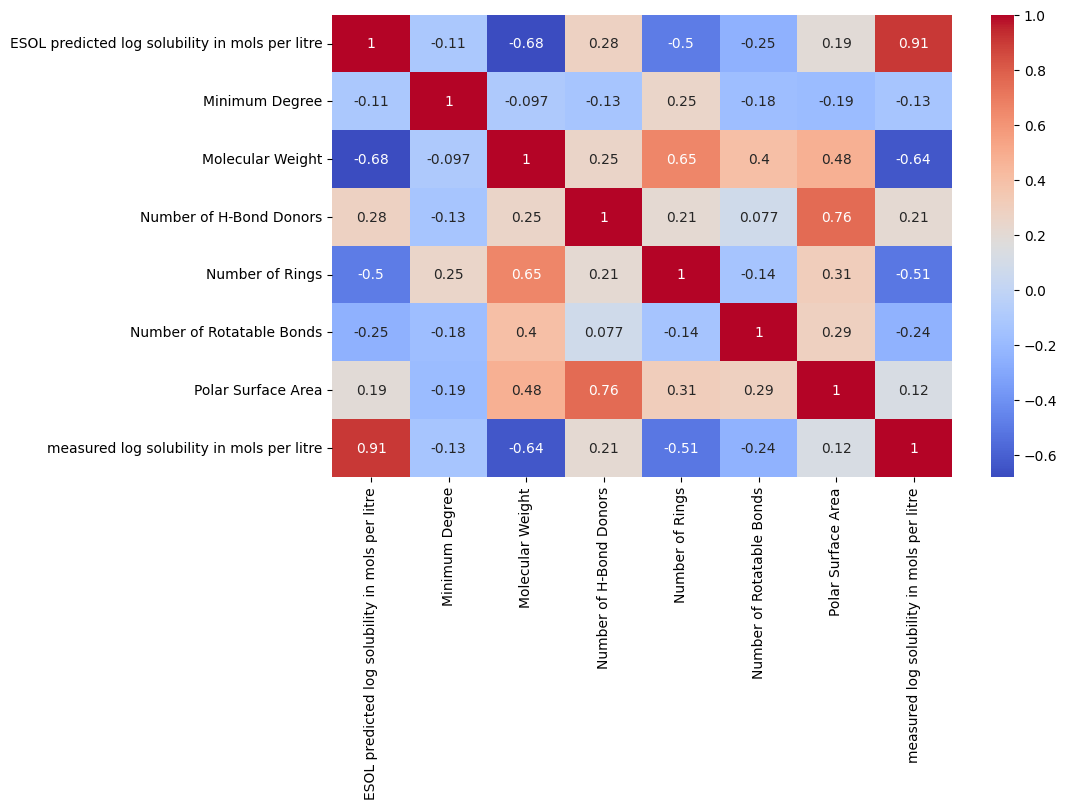

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [82]:
df.head()

,smiles,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
0,CC(C)=CCCC(C)=CC(=O),citral,-2.579,1,152.237,0,0,4,17.07,-2.06
1,CCCC=C,1-Pentene,-2.010,1,70.135,0,0,2,0.00,-2.68
2,CCCCCCCCCCCCCC,Tetradecane,-5.450,1,198.394,0,0,11,0.00,-7.96
3,CC(C)Cl,2-Chloropropane,-1.585,1,78.542,0,0,0,0.00,-1.41
4,CCC(C)CO,2-Methylbutanol,-1.027,1,88.150,1,0,2,20.23,-0.47


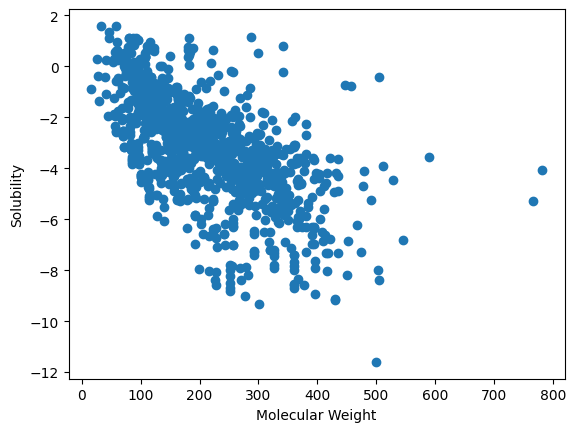

In [83]:
plt.scatter(df["Molecular Weight"], df["measured log solubility in mols per litre"])
plt.xlabel("Molecular Weight")
plt.ylabel("Solubility")
plt.show()

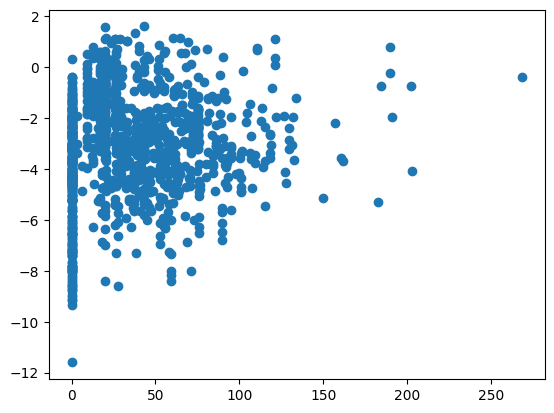

In [84]:
plt.scatter(df["Polar Surface Area"], df["measured log solubility in mols per litre"])
plt.show()

In [85]:
X = df.drop(columns=[
    "smiles",
    "Compound ID",
    "measured log solubility in mols per litre"
])

y = df["measured log solubility in mols per litre"]

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [87]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 0.41792438406889215


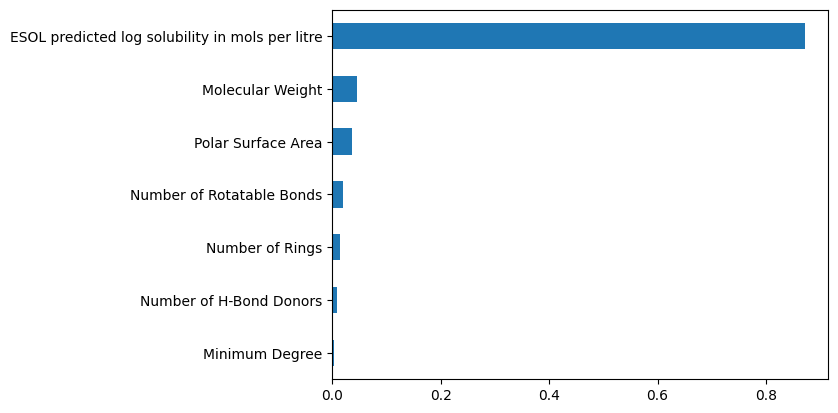

In [88]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh")
plt.show()

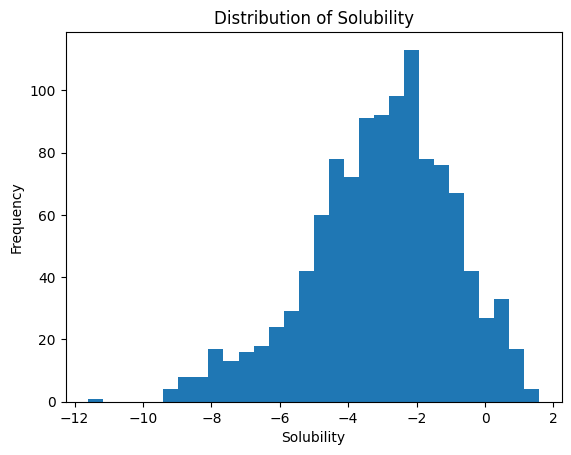

In [89]:
import matplotlib.pyplot as plt

plt.hist(df["measured log solubility in mols per litre"], bins=30)
plt.xlabel("Solubility")
plt.ylabel("Frequency")
plt.title("Distribution of Solubility")
plt.show()
# check wheather dataset is balanced , skeked

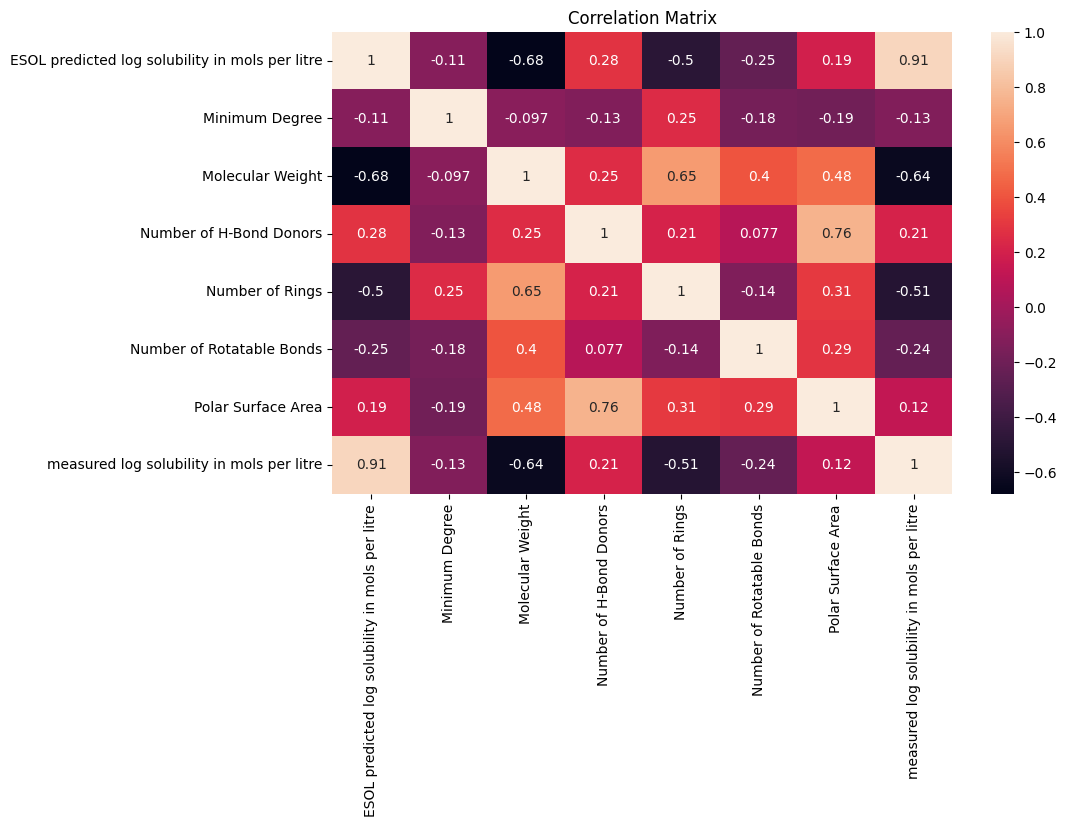

In [90]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

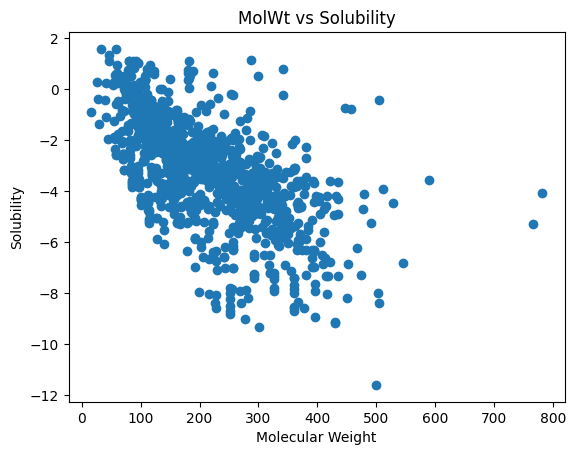

In [91]:
plt.scatter(df["Molecular Weight"], df["measured log solubility in mols per litre"])
plt.xlabel("Molecular Weight")
plt.ylabel("Solubility")
plt.title("MolWt vs Solubility")
plt.show()

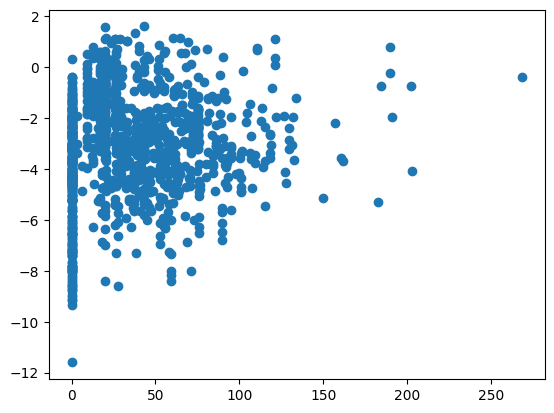

In [92]:
plt.scatter(df["Polar Surface Area"], df["measured log solubility in mols per litre"])
plt.show()

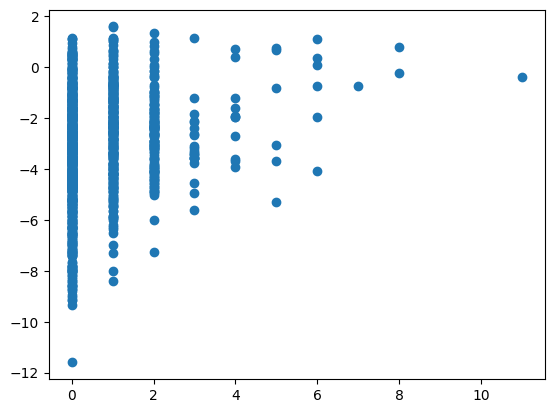

In [93]:
plt.scatter(df["Number of H-Bond Donors"], df["measured log solubility in mols per litre"])
plt.show()

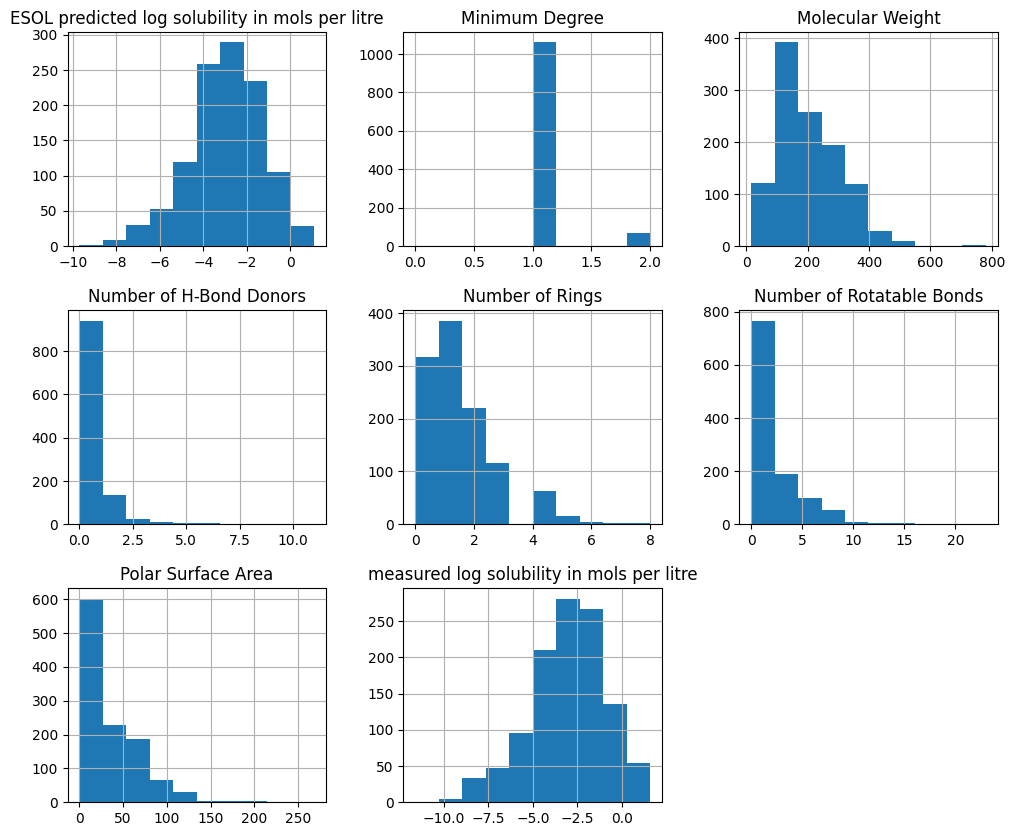

In [94]:
df.hist(figsize=(12,10))
plt.show()

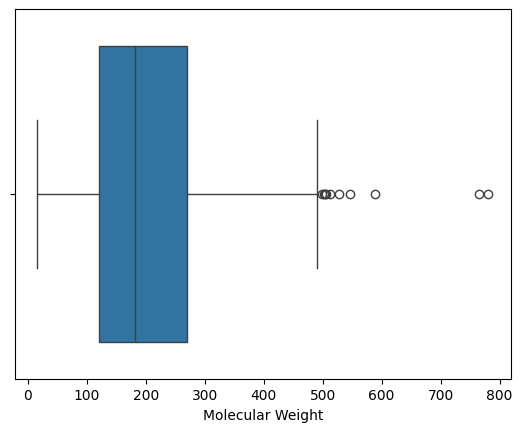

In [95]:
sns.boxplot(x=df["Molecular Weight"])
plt.show()

# Feature extraction


In [96]:
pip install rdkit

In [97]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors

In [98]:
def extract_features(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    features = {}

    # Basic descriptors
    features["MolWt"] = Descriptors.MolWt(mol)
    features["LogP"] = Descriptors.MolLogP(mol)
    features["NumHDonors"] = Descriptors.NumHDonors(mol)
    features["NumHAcceptors"] = Descriptors.NumHAcceptors(mol)
    features["TPSA"] = Descriptors.TPSA(mol)
    features["NumRotatableBonds"] = Descriptors.NumRotatableBonds(mol)
    features["NumRings"] = rdMolDescriptors.CalcNumRings(mol)

    return features

In [99]:
rdkit_features = df["smiles"].apply(extract_features)

rdkit_df = pd.DataFrame(rdkit_features.tolist())

rdkit_df.head()

,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumRings
0,152.237,2.8780,0,1,17.07,4,0
1,70.135,1.9725,0,0,0.00,2,0
2,198.394,5.7074,0,0,0.00,11,0
3,78.542,1.6336,0,0,0.00,0,0
4,88.150,1.0248,1,1,20.23,2,0


In [100]:
# merge with original data

df_final = pd.concat([df, rdkit_df], axis=1)

df_final.head()

,smiles,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumRings
0,CC(C)=CCCC(C)=CC(=O),citral,-2.579,1,152.237,0,0,4,17.07,-2.06,152.237,2.8780,0,1,17.07,4,0
1,CCCC=C,1-Pentene,-2.010,1,70.135,0,0,2,0.00,-2.68,70.135,1.9725,0,0,0.00,2,0
2,CCCCCCCCCCCCCC,Tetradecane,-5.450,1,198.394,0,0,11,0.00,-7.96,198.394,5.7074,0,0,0.00,11,0
3,CC(C)Cl,2-Chloropropane,-1.585,1,78.542,0,0,0,0.00,-1.41,78.542,1.6336,0,0,0.00,0,0
4,CCC(C)CO,2-Methylbutanol,-1.027,1,88.150,1,0,2,20.23,-0.47,88.150,1.0248,1,1,20.23,2,0


In [101]:
df_final = df_final.dropna()

In [102]:
print(df_final.columns)

Index(['smiles', 'Compound ID',
       'ESOL predicted log solubility in mols per litre', 'Minimum Degree',
       'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings',
       'Number of Rotatable Bonds', 'Polar Surface Area',
       'measured log solubility in mols per litre', 'MolWt', 'LogP',
       'NumHDonors', 'NumHAcceptors', 'TPSA', 'NumRotatableBonds', 'NumRings'],
      dtype='object')


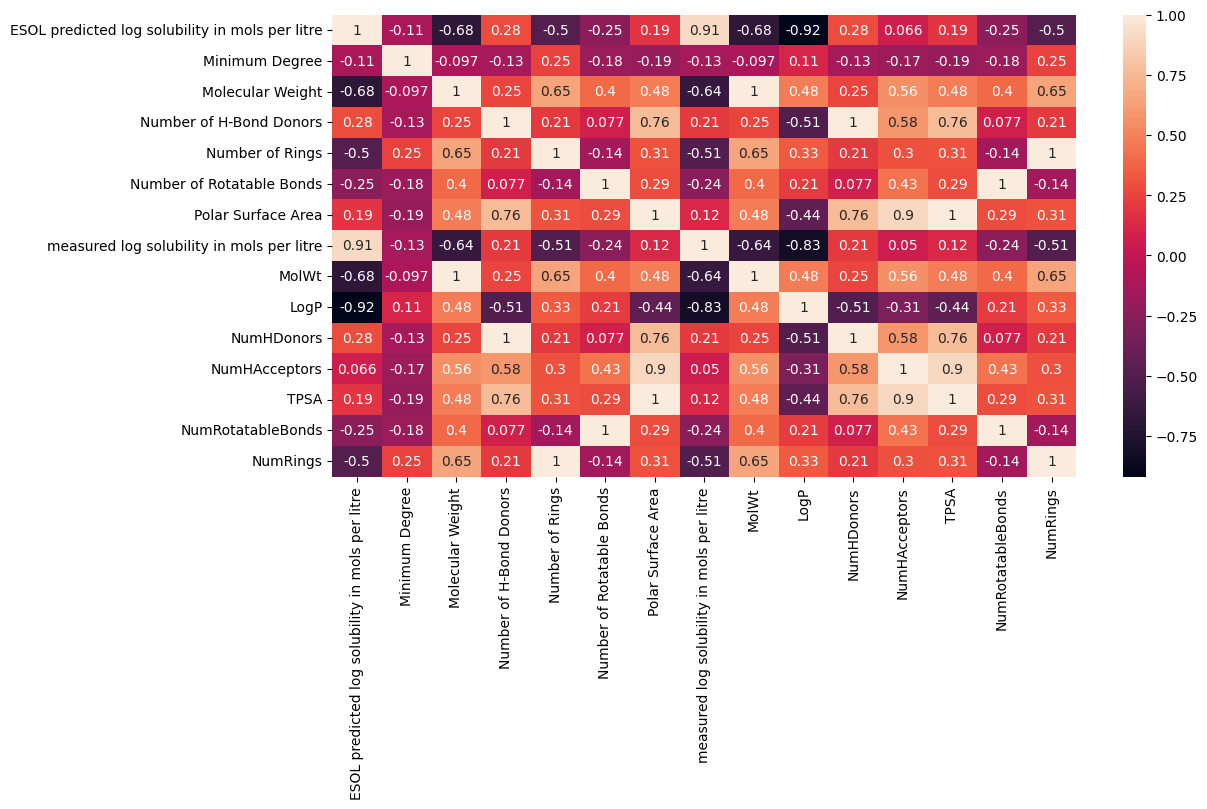

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df_final.corr(numeric_only=True), annot=True)
plt.show()

In [104]:
X = df_final[[
    "MolWt", "LogP", "NumHDonors",
    "NumHAcceptors", "TPSA",
    "NumRotatableBonds", "NumRings"
]]

y = df_final["measured log solubility in mols per litre"]

In [105]:
from rdkit.Chem import AllChem

def fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
    return list(fp)

fp_df = df["smiles"].apply(fingerprint)
fp_df = pd.DataFrame(fp_df.tolist())

[03:49:00] DEPRECATION WARNING: please use MorganGenerator
[03:49:00] DEPRECATION WARNING: please use MorganGenerator
[03:49:00] DEPRECATION WARNING: please use MorganGenerator
[03:49:00] DEPRECATION WARNING: please use MorganGenerator
[03:49:00] DEPRECATION WARNING: please use MorganGenerator
[03:49:00] DEPRECATION WARNING: please use MorganGenerator
[03:49:00] DEPRECATION WARNING: please use MorganGenerator
[03:49:00] DEPRECATION WARNING: please use MorganGenerator
[03:49:00] DEPRECATION WARNING: please use MorganGenerator
[03:49:00] DEPRECATION WARNING: please use MorganGenerator
[03:49:00] DEPRECATION WARNING: please use MorganGenerator
[03:49:00] DEPRECATION WARNING: please use MorganGenerator
[03:49:00] DEPRECATION WARNING: please use MorganGenerator
[03:49:00] DEPRECATION WARNING: please use MorganGenerator
[03:49:00] DEPRECATION WARNING: please use MorganGenerator
[03:49:00] DEPRECATION WARNING: please use MorganGenerator
[03:49:00] DEPRECATION WARNING: please use MorganGenerat

In [106]:
fp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [107]:
features = [
    "MolWt", "LogP", "NumHDonors",
    "NumHAcceptors", "TPSA",
    "NumRotatableBonds", "NumRings"
]

X = df_final[features]
y = df_final["measured log solubility in mols per litre"]

In [108]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [109]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [110]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [111]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)  # no scaling needed

y_pred_rf = rf.predict(X_test)

In [112]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [113]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(y_true, y_pred, name):
    print(f"--- {name} ---")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))
    print()

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_gb, "Gradient Boosting")

--- Linear Regression ---
MSE: 0.9948419927256992
R2: 0.7732206499749839

--- Random Forest ---
MSE: 0.5388933324797659
R2: 0.8771564926227714

--- Gradient Boosting ---
MSE: 0.5519709387614075
R2: 0.8741753849955107



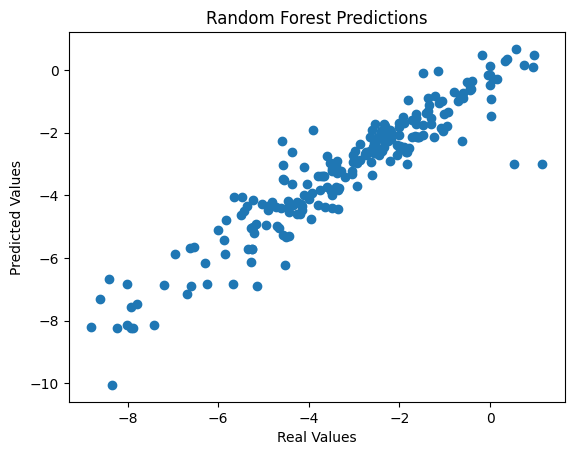

In [114]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Real Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Predictions")
plt.show()

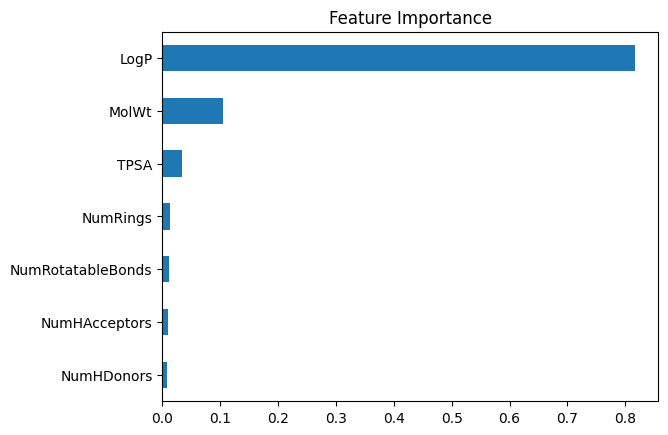

In [115]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [116]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=500, random_state=42)

DIFFERENT FINGERPRINT APPROACH

In [117]:
X = df_final[[
    "MolWt", "LogP", "NumHDonors",
    "NumHAcceptors", "TPSA",
    "NumRotatableBonds", "NumRings"
]]

y = df_final["measured log solubility in mols per litre"]

In [118]:
X["LogP_per_MW"] = X["LogP"] / X["MolWt"]
X["Polarity_Index"] = X["TPSA"] / X["MolWt"]
X["Flexibility"] = X["NumRotatableBonds"] / (X["NumRings"] + 1)

In [119]:
!pip install lightgbm

In [120]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6
)

model.fit(X, y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001802 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1328
[LightGBM] [Info] Number of data points in the train set: 1128, number of used features: 10
[LightGBM] [Info] Start training from score -3.050102
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

LGBMRegressor(learning_rate=0.05, max_depth=6, n_estimators=500)

In [121]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring="r2",verbose=False)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000177 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1283
[LightGBM] [Info] Number of data points in the train set: 902, number of used features: 10
[LightGBM] [Info] Start training from score -3.335958
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [122]:
print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.86429196 0.86335219 0.87252359 0.81912136 0.76901791]
Mean R2: 0.8376614018866035


# hyperparameter tuning + optimization

In [123]:
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [124]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV

model = LGBMRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "num_leaves": [15, 31, 63]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)


# Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 15}
# Best Score: 0.8356820923004241

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000177 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1328
[LightGBM] [Info] Number of data points in the train set: 1128, number of used features: 10
[LightGBM] [Info] Start training from score -3.050102
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [125]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    "n_estimators": np.arange(200, 1000, 100),
    "learning_rate": np.linspace(0.01, 0.2, 10),
    "max_depth": [3, 5, 7, 10],
    "num_leaves": [15, 31, 63, 127]
}

random_search = RandomizedSearchCV(
    model,
    param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X, y)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

# Best Params: {'num_leaves': 127, 'n_estimators': np.int64(200), 'max_depth': 3, 'learning_rate': np.float64(0.1577777777777778)}
# Best Score: 0.8341113814067077

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000158 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1328
[LightGBM] [Info] Number of data points in the train set: 1128, number of used features: 10
[LightGBM] [Info] Start training from score -3.050102
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [126]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X)


print("Final R2:", r2_score(y, y_pred))

Final R2: 0.950454592473644


In [127]:
from lightgbm import LGBMRegressor
from lightgbm import early_stopping, log_evaluation

model = LGBMRegressor(n_estimators=1000)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(0)   # disables logs
    ]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000154 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 663
[LightGBM] [Info] Number of data points in the train set: 902, number of used features: 7
[LightGBM] [Info] Start training from score -3.018649
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[77]	valid_0's rmse: 0.729329	valid_0's l2: 0.53192


LGBMRegressor(n_estimators=1000)